# Business Problem
## 📉 Telecom Customer Churn Analysis
### Objective
The goal of this analysis is to identify key factors driving customer churn and propose data-driven retention strategies.

### Business Problem
Customer churn leads to revenue loss and increased acquisition costs. By analyzing customer behavior, we aim to:
- Identify high-risk customers
- Understand churn patterns
- Recommend actionable retention strategies

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# Labelencoder- for categorical data encoding

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import picklel

In [160]:
df = pd.read_csv('../Telecom customerr churn/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [161]:
df.shape

(7043, 21)

In [162]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [163]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [164]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [165]:
# printing the number of unique values in each column
for column in df.columns:
    print(column, df[column].unique())
    print("-"*50)


customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSec

Data cleaning

In [166]:
# Drop customerID column as it is not useful for analysis
df.drop('customerID', axis=1, inplace=True)

In [167]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()
df.dropna(inplace=True)  # or fillna — justify your choice

In [168]:
# conver churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [169]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

## Hypotheses

1. Customers with shorter tenure are more likely to churn  
2. Month-to-month contracts increase churn risk  
3. Higher monthly charges lead to higher churn  
4. Payment method affects churn behavior  

Feature Engineering

In [ ]:
# Tenure buckets
def tenure_group(x):
    if x <= 5:
        return 'Critical'    # 48–62% churn
    elif x <= 15:
        return 'At Risk'     # 37–39% churn
    elif x <= 36:
        return 'Stabilizing' # gradually dropping
    else:
        return 'Loyal'       # very low churn

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Monthly charge segments
df['charge_group'] = pd.qcut(df['MonthlyCharges'], 3, labels=['Low', 'Medium', 'High'])
# qcut divides the data into 3 equal sized buckets based on quantiles.
#Bottom 33% of customers by monthly charges → Low
#Middle 33% → Medium
#Top 33% → High

# Customer value proxy
df['customer_value'] = df['MonthlyCharges'] * df['tenure']

### Exploratory Data Analysis

Overall Churn Rate

In [172]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

This says that out of all customers, 26% of customers have churned that is 1 in 4 customers leaving

<Axes: xlabel='Churn', ylabel='tenure'>

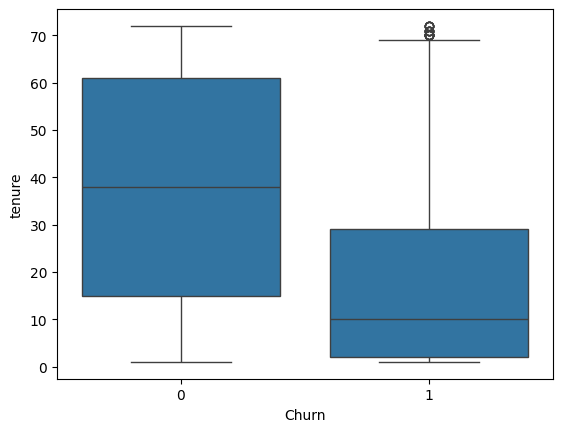

In [173]:
sns.boxplot(x='Churn', y='tenure', data=df)

Churn by tenure

In [174]:
df.groupby('Churn')['tenure'].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [175]:
pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False)


Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
...,...,...
62,92.857143,7.142857
63,94.444444,5.555556
64,95.000000,5.000000


In [176]:
# Create the crosstab, sort by Churn '1' descending, and take the top 10
(pd.crosstab(df['tenure'], df['Churn'], normalize='index') * 100).sort_values(by=1, ascending=False).head(10)

Churn,0,1
tenure,,
1,38.009788,61.990212
2,48.319328,51.680672
5,51.879699,48.120301
4,52.840909,47.159091
3,53.000000,47.000000
7,61.068702,38.931298
10,61.206897,38.793103
9,61.344538,38.655462
15,62.626263,37.373737


- Churn is highest within the first 5 months of customer tenure.  
- Customers with shorter tenure (< 17 months) have a significantly likelihood of churning.  
- Highlights the first ~1.5 years as a critical phase in the customer lifecycle.  
- Indicates potential gaps in onboarding, early engagement, or value realization.  
- Improving the early customer experience can significantly reduce churn.

Churn by Monthly charges

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

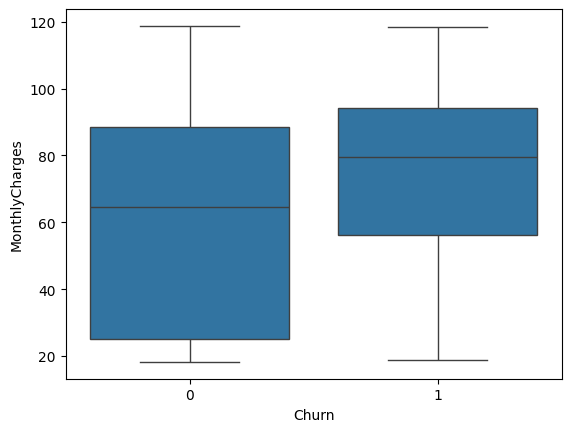

In [177]:
# Are churned customers paying more or less than non-churned customers?
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
df.groupby('Churn')['MonthlyCharges'].mean()



Churn
0    2555.344141
1    1531.796094
Name: TotalCharges, dtype: float64

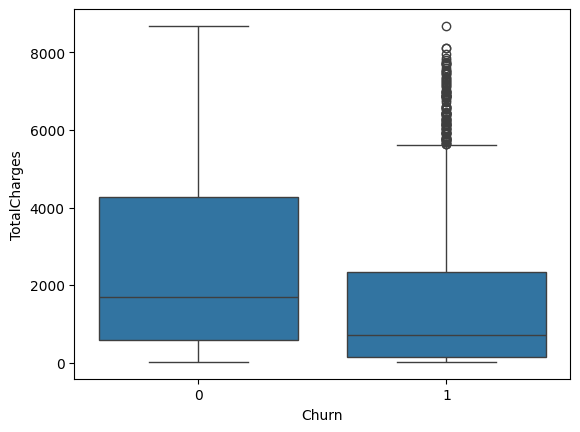

In [178]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)
df.groupby('Churn')['TotalCharges'].mean()

  
- Customers are paying more in the short term but not staying long enough to accumulate higher overall value.  
- Suggests a pattern of low tenure + high cost leading to dissatisfaction.  
- Lack of long-term commitment (e.g., month-to-month plans) makes it easier for customers to exit quickly.

Churn by Contract Type

In [179]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


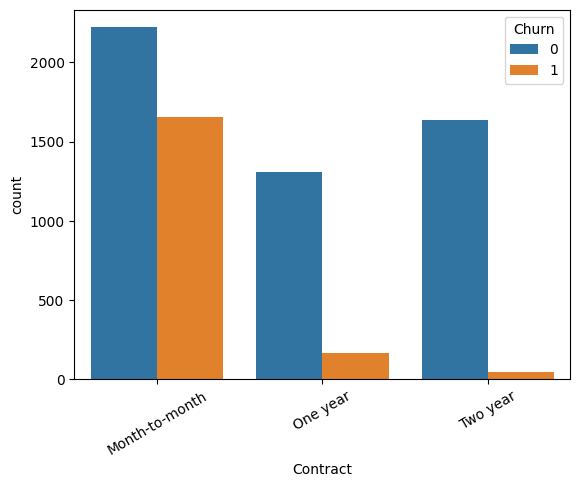

In [180]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

- They are new customers paying high price → then leaving early
-  High-paying new customers are churning early → pricing vs perceived value mismatch

In [181]:
pd.crosstab([df['Contract'], df['TechSupport']], df['Churn'], normalize='index')

Churn                                      0         1
Contract       TechSupport                            
Month-to-month No                   0.496269  0.503731
               No internet service  0.811069  0.188931
               Yes                  0.692996  0.307004
One year       No                   0.852783  0.147217
               No internet service  0.975207  0.024793
               Yes                  0.864130  0.135870
Two year       No                   0.940426  0.059574
               No internet service  0.992101  0.007899
               Yes                  0.964504  0.035496

Churn by Payment Method

In [182]:
# Payment behavior
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


Customers using electronic check have the highest probalility to churn.
- Less committed users
- Possibly more friction in payment

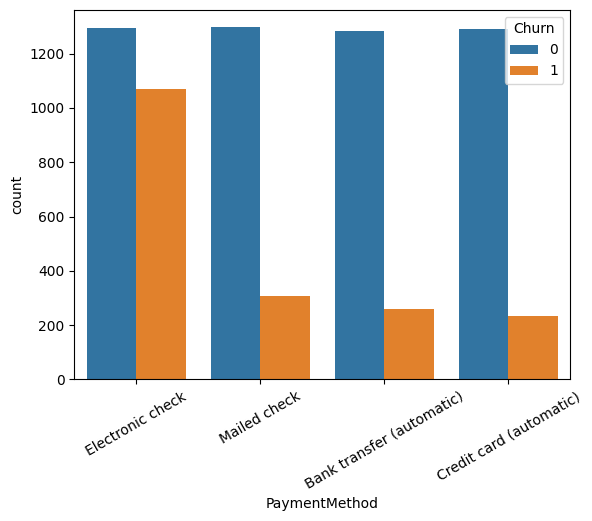

In [183]:
# visualize payment method vs churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

## Product engagement

In [184]:
# Service Usage
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,0,1
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


Customers opting for fibre optics are likely to churn. May linked to-
- Higher Pricing
- Higher expectations
- diff customer segement

In [185]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


- Customers with Online Security have a significantly lower churn rate (~14%) compared to those without it.  
- Customers without Online Security show a much higher tendency to churn.  


In [186]:
pd.crosstab(df['OnlineBackup'], df['Churn'], normalize='index') * 100

Churn,0,1
OnlineBackup,,
No,60.058309,39.941691
No internet service,92.565789,7.434211
Yes,78.432990,21.567010


- Customers with Online Backup services have a lower churn rate (~21%) compared to those without it (~39%).  
- Customers without Online Backup are significantly more likely to churn.  


In [187]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,0,1
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


- Customers with Tech Support show a significantly lower churn rate compared to those without it.  
- Customers without Tech Support are much more likely to churn.  


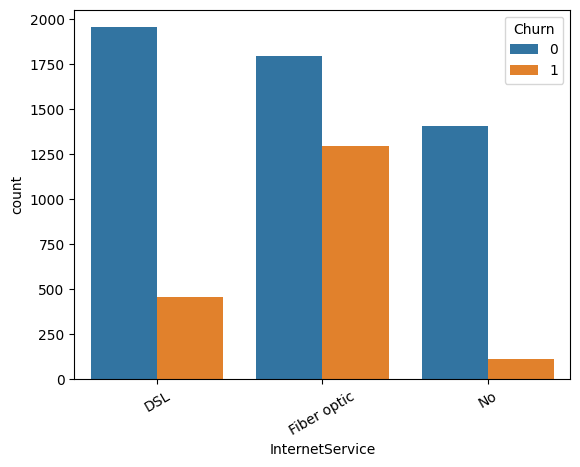

In [188]:
# Visualize internet service vs churn
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

### Insight
- Customers without support/utility services (Tech Support, Online Backup, Online Security) are significantly more likely to churn. 
- Indicates low engagement, weaker perceived value, and reduced product stickiness.  
- These services act as key retention drivers by building trust and increasing dependency.  

### Demographics

In [189]:
# Demographics
a = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
b = pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100
print(a)
print(b)

Churn                  0          1
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261
Churn               0          1
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205


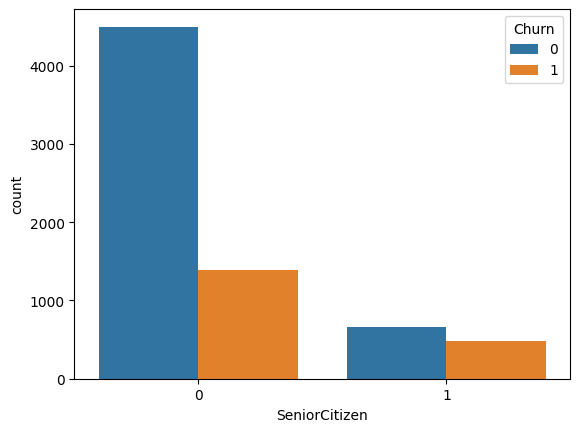

In [190]:
# Visulaize senior citizen vs churn
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.show()

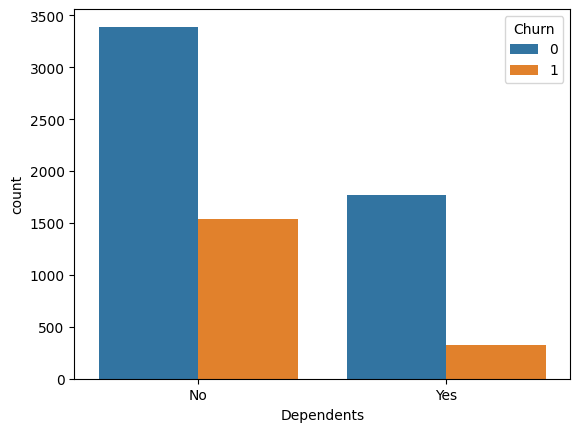

In [191]:
# Visualize dependents vs churn
sns.countplot(x='Dependents', hue='Churn', data=df)
plt.show()

- Senior citizens are more likely to churn compared to other age groups.  
- Customers without dependents also show a higher tendency to churn.  
- Indicates that customers with fewer ties or commitments are more likely to leave.

## Multi-factor Analysis

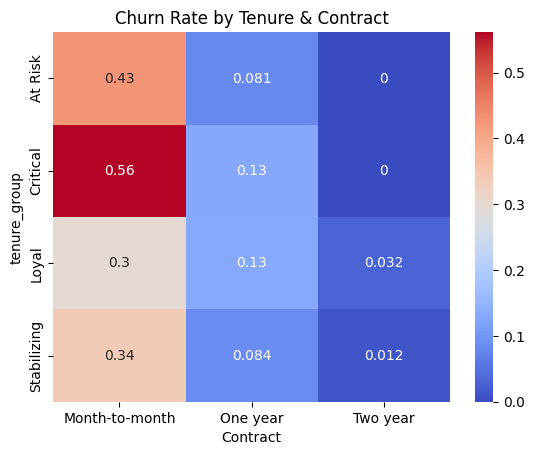

In [192]:
pivot = pd.crosstab(df['tenure_group'], df['Contract'], values=df['Churn'], aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Churn Rate by Tenure & Contract")
plt.show()

## Customer Segmentation
Segments derived by combining tenure-based risk zones 
(observed from churn patterns) with monthly charge levels.

In [217]:
def segment_customer(row):
    tenure = row['tenure_group']
    charge = row['charge_group']

    if tenure == 'Critical' and charge == 'High':
        return 'Danger Zone'
    elif tenure == 'Critical':
        return 'New - At Risk'
    elif tenure == 'At Risk' and charge == 'High':
        return 'Vulnerable'
    elif tenure in ['At Risk', 'Stabilizing']:
        return 'Growing'
    else:
        return 'Loyal'

df['segment'] = df.apply(segment_customer, axis=1)

In [226]:
# Churn rate + size per segment
segment_churn = df.groupby('segment')['Churn'].mean().sort_values(ascending=False) * 100
segment_size = df['segment'].value_counts()

segment_summary = pd.DataFrame({
    'Churn Rate (%)': (df.groupby('segment')['Churn'].mean() * 100).round(1),
    'Customer Count': df['segment'].value_counts(),
    'Avg Monthly Charges ($)': df.groupby('segment')['MonthlyCharges'].mean().round(2),
    'Avg Tenure (months)': df.groupby('segment')['tenure'].mean().round(1)
}).sort_values('Churn Rate (%)', ascending=False)

print(segment_summary)

               Churn Rate (%)  Customer Count  Avg Monthly Charges ($)  \
segment                                                                  
Danger Zone              78.2             188                    91.76   
Vulnerable               67.3             263                    93.32   
New - At Risk            50.9            1172                    48.75   
Growing                  24.5            2408                    58.40   
Loyal                    11.9            3001                    72.01   

               Avg Tenure (months)  
segment                             
Danger Zone                    2.7  
Vulnerable                    10.4  
New - At Risk                  2.2  
Growing                       20.2  
Loyal                         57.9  


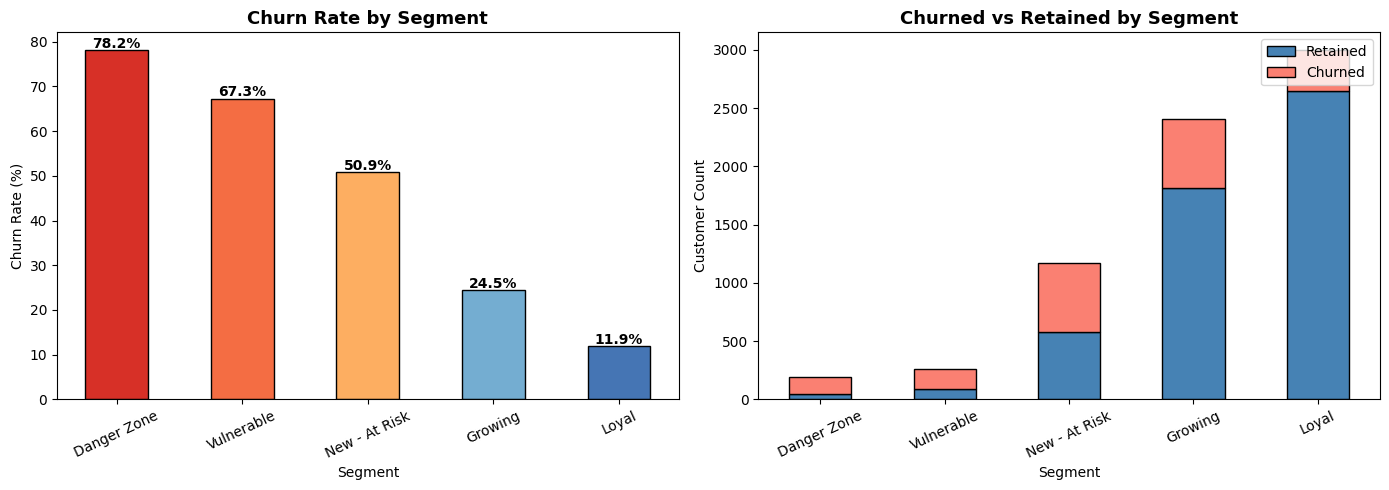

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Churn rate bar chart
colors = ['#d73027', '#f46d43', '#fdae61', '#74add1', '#4575b4']
bars = axes[0].bar(segment_summary.index, segment_summary['Churn Rate (%)'],
                   color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, segment_summary['Churn Rate (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Churn Rate by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Segment')
axes[0].tick_params(axis='x', rotation=25)

# Plot 2 — Stacked bar churned vs retained
segment_counts = df.groupby(['segment', 'Churn']).size().unstack()
segment_counts.columns = ['Retained', 'Churned']
segment_counts = segment_counts.loc[segment_summary.index]
segment_counts.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['steelblue', 'salmon'], edgecolor='black', width=0.5)
axes[1].set_title('Churned vs Retained by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Customer Count')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()




### Segment Insights
- **Danger Zone (78.2%)** — New customers paying high prices. Highest priority for intervention.
- **Vulnerable (67.3%)** — Past critical phase but still paying a lot. Need value reassurance.
- **New - At Risk (50.9%)** — Early stage, could go either way. Focus on onboarding.
- **Growing (24.5%)** — Heading in the right direction. Nudge toward annual contracts.
- **Loyal (11.9%)** — Most stable customers. Maintain with reward programs.

###  Are high-paying customers more likely to churn early?

In [195]:
# High-paying = top 25% monthly charges
high_pay_threshold = df['MonthlyCharges'].quantile(0.75)
high_paying = df[df['MonthlyCharges'] >= high_pay_threshold]

# Early churn = below median tenure
early_tenure_threshold = df['tenure'].median()
early_churners = high_paying[
    (high_paying['Churn'] == 1) &
    (high_paying['tenure'] <= early_tenure_threshold)
]

pct_high_pay_churning_early = (len(early_churners) / len(high_paying)) * 100

# Revenue at risk
total_revenue = df['TotalCharges'].sum()
revenue_at_risk = df[df['Churn'] == 1]['TotalCharges'].sum()
pct_revenue_at_risk = (revenue_at_risk / total_revenue) * 100

print(f"High-paying customers:              {len(high_paying)}")
print(f"...who churned early:               {len(early_churners)}")
print(f"% of high-payers churning early:    {pct_high_pay_churning_early:.1f}%")
print(f"\nTotal revenue:                      ${total_revenue:,.2f}")
print(f"Revenue at risk (churned):          ${revenue_at_risk:,.2f}")
print(f"% of revenue at risk:               {pct_revenue_at_risk:.1f}%")

High-paying customers:              1758
...who churned early:               308
% of high-payers churning early:    17.5%

Total revenue:                      $16,056,168.70
Revenue at risk (churned):          $2,862,926.90
% of revenue at risk:               17.8%


In [196]:
# List of people who are at risk of churning and have high value to the company

# Define thresholds for high value and at-risk customers
threshold_value = df['customer_value'].quantile(0.75)  # top 25% by value
threshold_churn = 1  # already churned or flagged

high_value_at_risk = df[
    (df['customer_value'] >= threshold_value) &
    (df['Churn'] == 1)
].sort_values('customer_value', ascending=False)

print(f"High-value at-risk customers: {len(high_value_at_risk)}")
print(high_value_at_risk[['customer_value', 'MonthlyCharges', 'TotalCharges', 'tenure', 'Contract', 'Churn']].head(10))

High-value at-risk customers: 254
      customer_value  MonthlyCharges  TotalCharges  tenure  Contract  Churn
4610         8481.60          117.80       8684.80      72  One year      1
6537         8095.50          115.65       7968.85      70  One year      1
1306         8088.50          115.55       8127.60      70  One year      1
6038         7994.00          114.20       7723.90      70  Two year      1
5127         7929.45          118.35       7804.15      67  One year      1
3890         7866.00          109.25       8109.80      72  One year      1
6289         7785.40          116.20       7752.30      67  Two year      1
3040         7710.60          108.60       7690.90      71  Two year      1
5581         7694.20          113.15       7856.00      68  Two year      1
975          7671.55          108.05       7532.15      71  Two year      1


### Business Impact analysis
Analyze high-paying early churners by contract type

In [197]:

for contract_type, group in df.groupby('Contract'):
    high_pay_threshold = group['MonthlyCharges'].quantile(0.75)
    high_paying = group[group['MonthlyCharges'] >= high_pay_threshold]
    early_tenure_threshold = group['tenure'].median()
    
    early_churners = high_paying[
        (high_paying['Churn'] == 1) &
        (high_paying['tenure'] <= early_tenure_threshold)
    ]
    
    total_revenue = group['TotalCharges'].sum()
    revenue_at_risk = group[group['Churn'] == 1]['TotalCharges'].sum()
    
    print(f"\n{'='*45}")
    print(f"Contract: {contract_type}")
    print(f"{'='*45}")
    print(f"Total customers:                  {len(group)}")
    print(f"High-paying customers:            {len(high_paying)}")
    print(f"...who churned early:             {len(early_churners)}")
    print(f"% of high-payers churning early:  {(len(early_churners)/len(high_paying)*100):.1f}%")
    print(f"Total revenue:                    ${total_revenue:,.2f}")
    print(f"Revenue at risk:                  ${revenue_at_risk:,.2f}")
    print(f"% revenue at risk:                {(revenue_at_risk/total_revenue*100):.1f}%")


Contract: Month-to-month
Total customers:                  3875
High-paying customers:            969
...who churned early:             190
% of high-payers churning early:  19.6%
Total revenue:                    $5,305,861.50
Revenue at risk:                  $1,927,182.25
% revenue at risk:                36.3%

Contract: One year
Total customers:                  1472
High-paying customers:            368
...who churned early:             21
% of high-payers churning early:  5.7%
Total revenue:                    $4,467,053.50
Revenue at risk:                  $674,991.20
% revenue at risk:                15.1%

Contract: Two year
Total customers:                  1685
High-paying customers:            422
...who churned early:             12
% of high-payers churning early:  2.8%
Total revenue:                    $6,283,253.70
Revenue at risk:                  $260,753.45
% revenue at risk:                4.1%


This clearly says that the month to month tenure gives the highest amount of revenue and also the highest amount of churn is there only.

### High value churners

In [198]:
high_value = df[df['customer_value'] >= df['customer_value'].quantile(0.75)]
high_value_churn = high_value[high_value['Churn'] == 1]

### Contract Type

In [199]:
high_value_churn['Contract'].value_counts(normalize=True)*100

Contract
Month-to-month    50.393701
One year          34.645669
Two year          14.960630
Name: proportion, dtype: float64

In [200]:
# Monthly charges 
high_value_churn['MonthlyCharges'].describe()

count    254.000000
mean      99.488386
std       10.194529
min       54.200000
25%       94.812500
50%      101.450000
75%      106.000000
max      118.350000
Name: MonthlyCharges, dtype: float64

In [201]:
high_value_churn['tenure'].describe()

count    254.000000
mean      55.661417
std        9.710204
min       37.000000
25%       48.000000
50%       55.000000
75%       65.000000
max       72.000000
Name: tenure, dtype: float64

In [202]:
high_value_churn['PaymentMethod'].value_counts(normalize=True)*100

PaymentMethod
Electronic check             50.787402
Bank transfer (automatic)    25.590551
Credit card (automatic)      20.866142
Mailed check                  2.755906
Name: proportion, dtype: float64

In [203]:
cols = ['InternetService', 'OnlineSecurity', 'TechSupport']
for col in cols:
    print(high_value_churn[col].value_counts(normalize=True)*100)

InternetService
Fiber optic    94.488189
DSL             5.511811
Name: proportion, dtype: float64
OnlineSecurity
No     67.322835
Yes    32.677165
Name: proportion, dtype: float64
TechSupport
No     65.354331
Yes    34.645669
Name: proportion, dtype: float64


### Churn rate for month-to-month (overall vs high-value)

In [204]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [205]:
pd.crosstab(high_value['Contract'], high_value['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-month,67.758186,32.241814
One year,83.763838,16.236162
Two year,95.360195,4.639805


High-value customers are MORE LOYAL overall
- While high-value customers show lower churn in flexible (month-to-month) plans, they exhibit higher churn rates in long-term contracts, suggesting that contractual lock-in is less effective in retaining premium users
- High-value customers are not price-sensitive impulsive churners
They are experience-driven churners

In [206]:
# Why are high-value users churning even in long-term contracts?
long_term_high_value_churn = df[
    (df['customer_value'] >= df['customer_value'].quantile(0.75)) &
    (df['Churn'] == 1) &
    (df['Contract'].isin(['One year', 'Two year']))
]

In [207]:
long_term_high_value_churn['TechSupport'].value_counts(normalize=True) * 100

TechSupport
Yes    52.380952
No     47.619048
Name: proportion, dtype: float64

In [208]:
long_term_high_value_churn['OnlineSecurity'].value_counts(normalize=True) * 100

OnlineSecurity
No     55.555556
Yes    44.444444
Name: proportion, dtype: float64

In [209]:
long_term_high_value_churn['InternetService'].value_counts(normalize=True) * 100

InternetService
Fiber optic    88.888889
DSL            11.111111
Name: proportion, dtype: float64

In [210]:
long_term_high_value_nonchurn = df[
    (df['customer_value'] >= df['customer_value'].quantile(0.75)) &
    (df['Churn'] == 0) &
    (df['Contract'].isin(['One year', 'Two year']))
]

In [211]:
print("Churners:\n", long_term_high_value_churn['TechSupport'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['TechSupport'].value_counts(normalize=True) * 100)

Churners:
 TechSupport
Yes    52.380952
No     47.619048
Name: proportion, dtype: float64

Non-Churners:
 TechSupport
Yes    68.259109
No     31.740891
Name: proportion, dtype: float64


In [212]:
print("Churners:\n", long_term_high_value_churn['OnlineSecurity'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['OnlineSecurity'].value_counts(normalize=True) * 100)

Churners:
 OnlineSecurity
No     55.555556
Yes    44.444444
Name: proportion, dtype: float64

Non-Churners:
 OnlineSecurity
Yes    65.101215
No     34.898785
Name: proportion, dtype: float64


In [213]:
print("Churners:\n", long_term_high_value_churn['InternetService'].value_counts(normalize=True) * 100)
print("\nNon-Churners:\n", long_term_high_value_nonchurn['InternetService'].value_counts(normalize=True) * 100)

Churners:
 InternetService
Fiber optic    88.888889
DSL            11.111111
Name: proportion, dtype: float64

Non-Churners:
 InternetService
Fiber optic    59.676113
DSL            40.323887
Name: proportion, dtype: float64


- Even among high-value customers with long-term contracts, churn is significantly higher for fiber optic users who lack support services. 
- This suggests that retention failure is driven by unmet service expectations rather than contract structure or pricing.